# MA-SpecFormer Reconstruction Benchmark

This notebook visualizes the reconstruction quality of the trained MA-SpecFormer model by comparing original spectra with their reconstructed counterparts from the test (validation) split.

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from model.ma_specformer import MASpecFormer
from data.datamodule import MASpectrumDataModule

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/lightning/fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


Using device: cuda


## Load Checkpoint and Data

In [2]:
checkpoint_path = "/u/yacheng/projects/ssl_outthere/encoder_spectrum/ma_specformer/output/checkpoints/last.ckpt"
    
print(f"Loading checkpoint: {checkpoint_path}")

# Load model from checkpoint
model = MASpecFormer.load_from_checkpoint(checkpoint_path, map_location=device)
model.eval()
model.to(device)
print(f"Model loaded with {sum(p.numel() for p in model.parameters()):,} parameters")

Loading checkpoint: /u/yacheng/projects/ssl_outthere/encoder_spectrum/ma_specformer/output/checkpoints/last.ckpt
Model loaded with 3,253 parameters


In [4]:
# Load the data module (same configuration as training)
h5_path = "/u/yacheng/projects/ssl_outthere/images/OUTTHERE/spectrum/f150w.h5"

data_module = MASpectrumDataModule(
    h5_path=h5_path,
    batch_size=32,
    num_workers=0,
    train_val_split=0.9,
    min_snr=5.0,
)

# Setup the data
data_module.setup()

# Get test/validation dataloader
test_loader = data_module.test_dataloader()
print(f"Test set size: {len(data_module.val_dataset)} samples")

SNR filtering: 10339/30199 samples with SNR >= 5.0
Test set size: 1034 samples


## Reconstruction Function

Define a function to perform masked reconstruction and visualize the results.

In [5]:
def normalize_flux(flux, valid_mask, min_std=0.2):
    """Normalize flux per-sample using valid positions only."""
    B, T = flux.shape
    
    # Compute mean and std using only valid positions
    valid_flux = flux.clone()
    valid_flux[~valid_mask] = 0.0
    
    valid_count = valid_mask.sum(dim=1, keepdim=True).float().clamp(min=1)
    mean = valid_flux.sum(dim=1, keepdim=True) / valid_count
    
    sq_diff = ((flux - mean) ** 2) * valid_mask.float()
    var = sq_diff.sum(dim=1, keepdim=True) / valid_count
    std = var.sqrt().clamp(min=min_std)
    
    normalized_flux = (flux - mean) / std
    normalized_flux = normalized_flux * valid_mask.float()
    
    return normalized_flux, mean, std


def mask_input(flux, valid_mask, mask_ratio=0.3, min_unmasked=10):
    """Apply random mask to flux values."""
    B, T = flux.shape
    
    masked_flux = flux.clone()
    train_mask = torch.zeros(B, T, dtype=torch.bool, device=flux.device)
    
    for i in range(B):
        valid_indices = valid_mask[i].nonzero(as_tuple=True)[0]
        num_valid = len(valid_indices)
        
        if num_valid > min_unmasked:
            num_to_mask = max(1, int(num_valid * mask_ratio))
            perm = torch.randperm(num_valid, device=flux.device)[:num_to_mask]
            mask_indices = valid_indices[perm]
            masked_flux[i, mask_indices] = 0.0
            train_mask[i, mask_indices] = True
    
    return masked_flux, train_mask


@torch.no_grad()
def reconstruct_batch(model, batch, mask_ratio=0.3):
    """
    Reconstruct a batch of spectra with masking.
    
    Returns:
        dict with original, masked input, reconstruction, and mask info
    """
    flux = batch["flux"].to(device)
    wavelength = batch["wavelength"].to(device)
    valid_mask = batch["valid_mask"].to(device)
    
    # Normalize flux
    flux_norm, mean, std = normalize_flux(flux, valid_mask)
    
    # Apply masking
    input_flux, train_mask = mask_input(flux_norm, valid_mask, mask_ratio=mask_ratio)
    
    # Forward pass
    embeddings = model.encode(input_flux, wavelength, valid_mask, normalize=False)
    reconstructions = model.head(embeddings).squeeze(-1)
    
    # Denormalize for visualization
    original_denorm = flux_norm  # Keep normalized for comparison
    recon_denorm = reconstructions  # Reconstruction is already in normalized space
    
    return {
        "original": flux.cpu().numpy(),
        "original_norm": flux_norm.cpu().numpy(),
        "masked_input": input_flux.cpu().numpy(),
        "reconstruction": reconstructions.cpu().numpy(),
        "wavelength": wavelength.cpu().numpy(),
        "valid_mask": valid_mask.cpu().numpy(),
        "train_mask": train_mask.cpu().numpy(),
        "mean": mean.cpu().numpy(),
        "std": std.cpu().numpy(),
    }

## Visualize Reconstruction Examples

Get a batch from the test set and visualize several reconstruction examples.

In [6]:
# Get one batch from test set
test_batch = next(iter(test_loader))

# Perform reconstruction with 30% masking (same as training)
results = reconstruct_batch(model, test_batch, mask_ratio=0.3)

print(f"Batch shape: {results['original'].shape}")
print(f"Wavelength range: {results['wavelength'].min():.1f} - {results['wavelength'].max():.1f} Angstrom")

Batch shape: (32, 99)
Wavelength range: 12819.2 - 17193.4 Angstrom


In [7]:
def plot_reconstruction_comparison(results, sample_indices, figsize=(14, 4)):
    """Plot original vs reconstructed spectra for given sample indices.
    
    Args:
        results: dict from reconstruct_batch()
        sample_indices: list of sample indices to plot
        figsize: figure size per sample
    """
    n_samples = len(sample_indices)
    fig, axes = plt.subplots(n_samples, 1, figsize=(figsize[0], figsize[1] * n_samples))
    
    if n_samples == 1:
        axes = [axes]
    
    for ax, idx in zip(axes, sample_indices):
        wavelength = results["wavelength"][idx]
        original = results["original_norm"][idx]
        reconstruction = results["reconstruction"][idx]
        valid_mask = results["valid_mask"][idx].astype(bool)
        train_mask = results["train_mask"][idx].astype(bool)
        
        # Plot only valid positions
        wl_valid = wavelength[valid_mask]
        orig_valid = original[valid_mask]
        recon_valid = reconstruction[valid_mask]
        mask_valid = train_mask[valid_mask]
        
        # Sort by wavelength for proper line plot
        sort_idx = np.argsort(wl_valid)
        wl_sorted = wl_valid[sort_idx]
        orig_sorted = orig_valid[sort_idx]
        recon_sorted = recon_valid[sort_idx]
        mask_sorted = mask_valid[sort_idx]
        
        # Plot original spectrum
        ax.plot(wl_sorted, orig_sorted, 'b-', alpha=0.7, linewidth=1, label='Original (normalized)')
        
        # Plot reconstruction
        ax.plot(wl_sorted, recon_sorted, 'r-', alpha=0.7, linewidth=1, label='Reconstruction')
        
        # Highlight masked positions (where reconstruction matters)
        wl_masked = wl_sorted[mask_sorted]
        orig_masked = orig_sorted[mask_sorted]
        recon_masked = recon_sorted[mask_sorted]
        
        ax.scatter(wl_masked, orig_masked, c='blue', s=15, alpha=0.8, marker='o', label='Masked positions (original)')
        ax.scatter(wl_masked, recon_masked, c='red', s=15, alpha=0.8, marker='x', label='Masked positions (recon)')
        
        # Compute MSE on masked positions
        mse_masked = np.mean((orig_masked - recon_masked) ** 2) if len(orig_masked) > 0 else 0
        
        ax.set_xlabel('Wavelength (Å)')
        ax.set_ylabel('Normalized Flux')
        ax.set_title(f'Sample {idx} | Masked positions: {mask_sorted.sum()} | MSE (masked): {mse_masked:.4f}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return fig

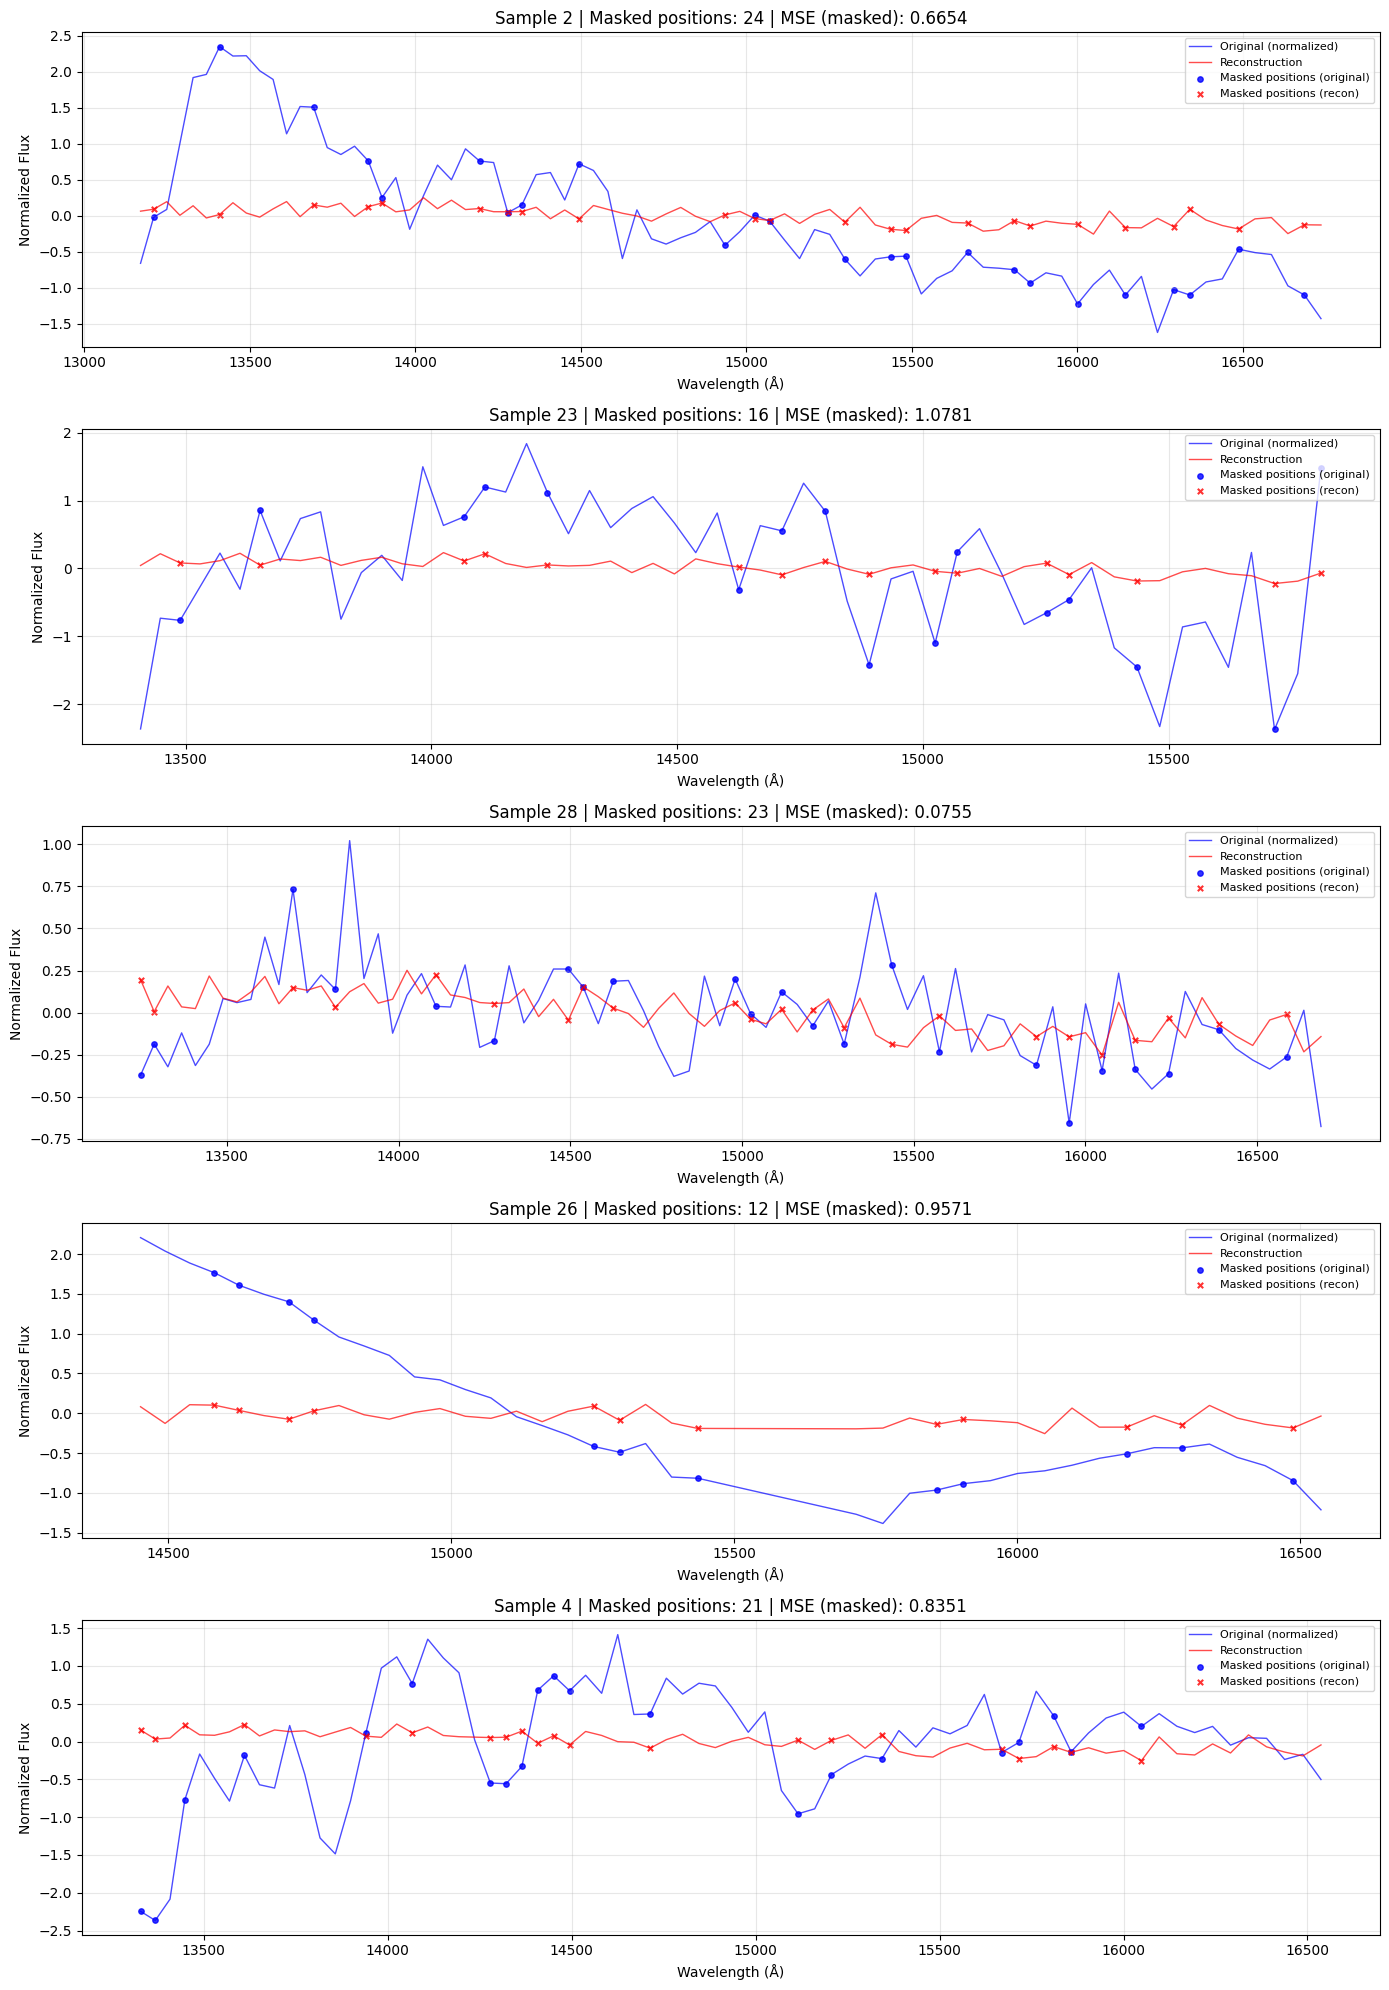

In [18]:
# Plot first 6 samples from test batch
sample_indices = np.random.randint(0,32,5)
fig = plot_reconstruction_comparison(results, sample_indices)

#check std deviaion.

## Detailed Single Sample View

Zoom in on a single sample to see the reconstruction quality in detail.

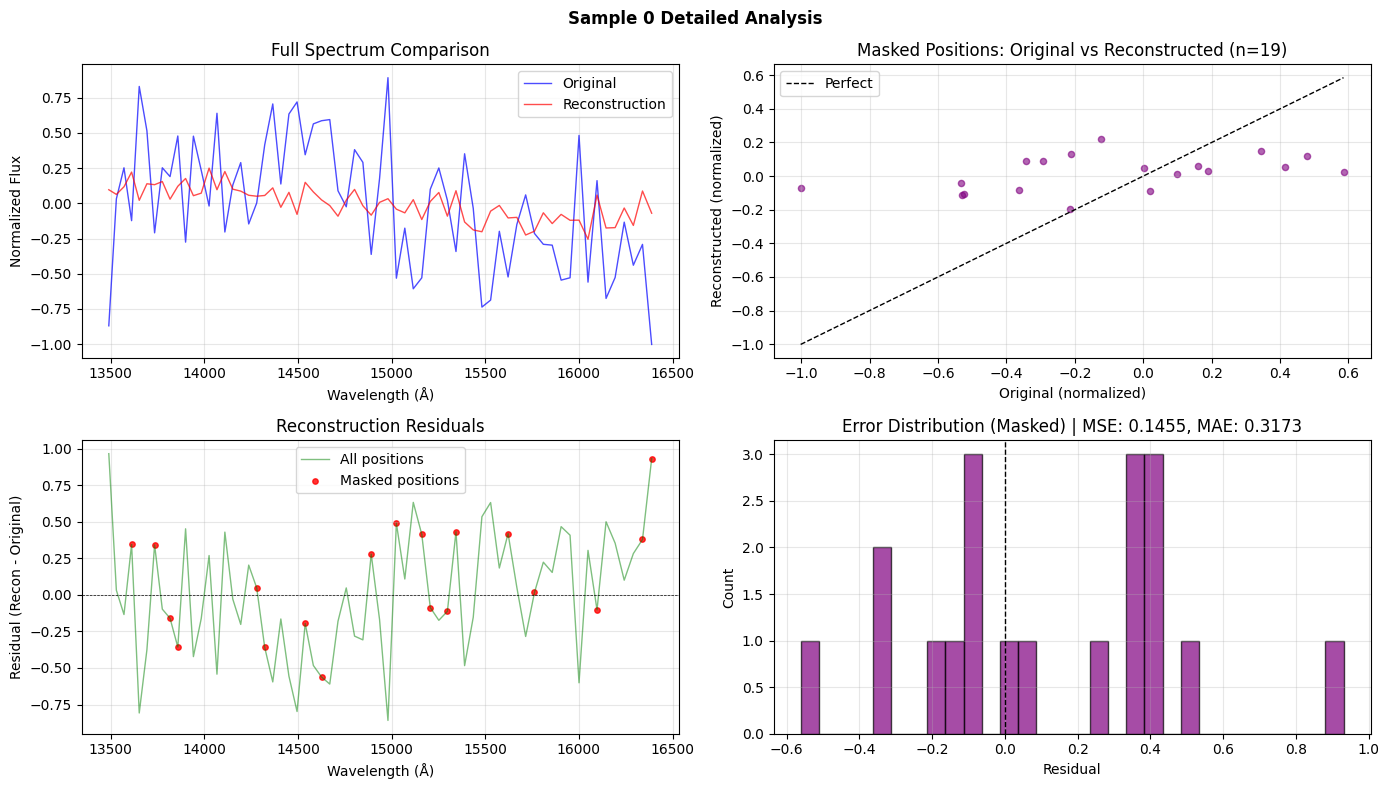

In [19]:
def plot_detailed_reconstruction(results, sample_idx, figsize=(14, 8)):
    """Plot detailed reconstruction analysis for a single sample."""
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    wavelength = results["wavelength"][sample_idx]
    original = results["original_norm"][sample_idx]
    reconstruction = results["reconstruction"][sample_idx]
    valid_mask = results["valid_mask"][sample_idx].astype(bool)
    train_mask = results["train_mask"][sample_idx].astype(bool)
    
    # Get valid positions
    wl_valid = wavelength[valid_mask]
    orig_valid = original[valid_mask]
    recon_valid = reconstruction[valid_mask]
    mask_valid = train_mask[valid_mask]
    
    # Sort by wavelength
    sort_idx = np.argsort(wl_valid)
    wl_sorted = wl_valid[sort_idx]
    orig_sorted = orig_valid[sort_idx]
    recon_sorted = recon_valid[sort_idx]
    mask_sorted = mask_valid[sort_idx]
    
    # 1. Full spectrum comparison
    ax1 = axes[0, 0]
    ax1.plot(wl_sorted, orig_sorted, 'b-', alpha=0.7, linewidth=1, label='Original')
    ax1.plot(wl_sorted, recon_sorted, 'r-', alpha=0.7, linewidth=1, label='Reconstruction')
    ax1.set_xlabel('Wavelength (Å)')
    ax1.set_ylabel('Normalized Flux')
    ax1.set_title('Full Spectrum Comparison')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Masked positions only
    ax2 = axes[0, 1]
    wl_masked = wl_sorted[mask_sorted]
    orig_masked = orig_sorted[mask_sorted]
    recon_masked = recon_sorted[mask_sorted]
    
    ax2.scatter(orig_masked, recon_masked, c='purple', s=20, alpha=0.6)
    
    # Perfect reconstruction line
    lim_min = min(orig_masked.min(), recon_masked.min()) if len(orig_masked) > 0 else -3
    lim_max = max(orig_masked.max(), recon_masked.max()) if len(orig_masked) > 0 else 3
    ax2.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', linewidth=1, label='Perfect')
    
    ax2.set_xlabel('Original (normalized)')
    ax2.set_ylabel('Reconstructed (normalized)')
    ax2.set_title(f'Masked Positions: Original vs Reconstructed (n={len(orig_masked)})')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Residuals (reconstruction error)
    ax3 = axes[1, 0]
    residuals_all = recon_sorted - orig_sorted
    residuals_masked = recon_masked - orig_masked if len(recon_masked) > 0 else np.array([])
    
    ax3.plot(wl_sorted, residuals_all, 'g-', alpha=0.5, linewidth=1, label='All positions')
    if len(wl_masked) > 0:
        ax3.scatter(wl_masked, residuals_masked, c='red', s=15, alpha=0.8, label='Masked positions')
    ax3.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax3.set_xlabel('Wavelength (Å)')
    ax3.set_ylabel('Residual (Recon - Original)')
    ax3.set_title('Reconstruction Residuals')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Error histogram
    ax4 = axes[1, 1]
    if len(residuals_masked) > 0:
        ax4.hist(residuals_masked, bins=30, alpha=0.7, color='purple', edgecolor='black')
        mse = np.mean(residuals_masked ** 2)
        mae = np.mean(np.abs(residuals_masked))
        ax4.axvline(x=0, color='k', linestyle='--', linewidth=1)
        ax4.set_title(f'Error Distribution (Masked) | MSE: {mse:.4f}, MAE: {mae:.4f}')
    else:
        ax4.set_title('No masked positions')
    ax4.set_xlabel('Residual')
    ax4.set_ylabel('Count')
    ax4.grid(True, alpha=0.3)
    
    plt.suptitle(f'Sample {sample_idx} Detailed Analysis', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

# Show detailed view for sample 0
fig = plot_detailed_reconstruction(results, sample_idx=0)

## Batch-level Reconstruction Statistics

Compute reconstruction metrics across the entire batch.

In [10]:
def compute_batch_metrics(results):
    """Compute reconstruction metrics across the batch."""
    B = results["original_norm"].shape[0]
    
    all_mse_masked = []
    all_mae_masked = []
    all_mse_all = []
    all_mae_all = []
    
    for i in range(B):
        valid_mask = results["valid_mask"][i].astype(bool)
        train_mask = results["train_mask"][i].astype(bool)
        
        orig = results["original_norm"][i][valid_mask]
        recon = results["reconstruction"][i][valid_mask]
        mask = train_mask[valid_mask]
        
        # All valid positions
        if len(orig) > 0:
            mse_all = np.mean((orig - recon) ** 2)
            mae_all = np.mean(np.abs(orig - recon))
            all_mse_all.append(mse_all)
            all_mae_all.append(mae_all)
        
        # Masked positions only
        orig_masked = orig[mask]
        recon_masked = recon[mask]
        if len(orig_masked) > 0:
            mse_masked = np.mean((orig_masked - recon_masked) ** 2)
            mae_masked = np.mean(np.abs(orig_masked - recon_masked))
            all_mse_masked.append(mse_masked)
            all_mae_masked.append(mae_masked)
    
    return {
        "mse_masked_mean": np.mean(all_mse_masked),
        "mse_masked_std": np.std(all_mse_masked),
        "mae_masked_mean": np.mean(all_mae_masked),
        "mae_masked_std": np.std(all_mae_masked),
        "mse_all_mean": np.mean(all_mse_all),
        "mse_all_std": np.std(all_mse_all),
        "mae_all_mean": np.mean(all_mae_all),
        "mae_all_std": np.std(all_mae_all),
        "per_sample_mse_masked": all_mse_masked,
        "per_sample_mse_all": all_mse_all,
    }

# Compute metrics
metrics = compute_batch_metrics(results)

print("=" * 50)
print("Reconstruction Metrics (Test Batch)")
print("=" * 50)
print(f"\nMasked Positions Only:")
print(f"  MSE: {metrics['mse_masked_mean']:.4f} ± {metrics['mse_masked_std']:.4f}")
print(f"  MAE: {metrics['mae_masked_mean']:.4f} ± {metrics['mae_masked_std']:.4f}")
print(f"\nAll Valid Positions:")
print(f"  MSE: {metrics['mse_all_mean']:.4f} ± {metrics['mse_all_std']:.4f}")
print(f"  MAE: {metrics['mae_all_mean']:.4f} ± {metrics['mae_all_std']:.4f}")

Reconstruction Metrics (Test Batch)

Masked Positions Only:
  MSE: 0.3970 ± 0.4035
  MAE: 0.4362 ± 0.2656

All Valid Positions:
  MSE: 0.4252 ± 0.3829
  MAE: 0.4355 ± 0.2402


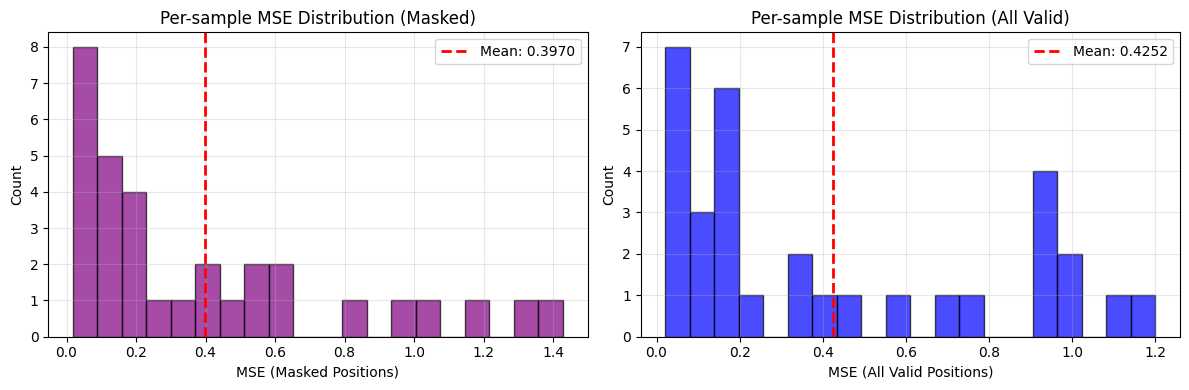

In [11]:
# Plot per-sample MSE distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
ax1.hist(metrics["per_sample_mse_masked"], bins=20, alpha=0.7, color='purple', edgecolor='black')
ax1.axvline(x=metrics["mse_masked_mean"], color='red', linestyle='--', linewidth=2, label=f'Mean: {metrics["mse_masked_mean"]:.4f}')
ax1.set_xlabel('MSE (Masked Positions)')
ax1.set_ylabel('Count')
ax1.set_title('Per-sample MSE Distribution (Masked)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.hist(metrics["per_sample_mse_all"], bins=20, alpha=0.7, color='blue', edgecolor='black')
ax2.axvline(x=metrics["mse_all_mean"], color='red', linestyle='--', linewidth=2, label=f'Mean: {metrics["mse_all_mean"]:.4f}')
ax2.set_xlabel('MSE (All Valid Positions)')
ax2.set_ylabel('Count')
ax2.set_title('Per-sample MSE Distribution (All Valid)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluate on Multiple Batches

Run reconstruction on multiple batches to get more robust statistics.

In [12]:
# Evaluate on multiple batches for more robust statistics
num_batches = 10
all_mse_masked = []
all_mse_all = []

test_iter = iter(test_loader)
for batch_idx in range(num_batches):
    try:
        batch = next(test_iter)
    except StopIteration:
        break
    
    results = reconstruct_batch(model, batch, mask_ratio=0.3)
    metrics = compute_batch_metrics(results)
    
    all_mse_masked.extend(metrics["per_sample_mse_masked"])
    all_mse_all.extend(metrics["per_sample_mse_all"])

print(f"Evaluated on {len(all_mse_masked)} samples from {batch_idx + 1} batches")
print(f"\nOverall Reconstruction Quality:")
print(f"  MSE (masked positions): {np.mean(all_mse_masked):.4f} ± {np.std(all_mse_masked):.4f}")
print(f"  MSE (all valid positions): {np.mean(all_mse_all):.4f} ± {np.std(all_mse_all):.4f}")

Evaluated on 320 samples from 10 batches

Overall Reconstruction Quality:
  MSE (masked positions): 0.4796 ± 0.4490
  MSE (all valid positions): 0.4972 ± 0.3837


## Test with Different Mask Ratios

Evaluate reconstruction quality at different masking levels.

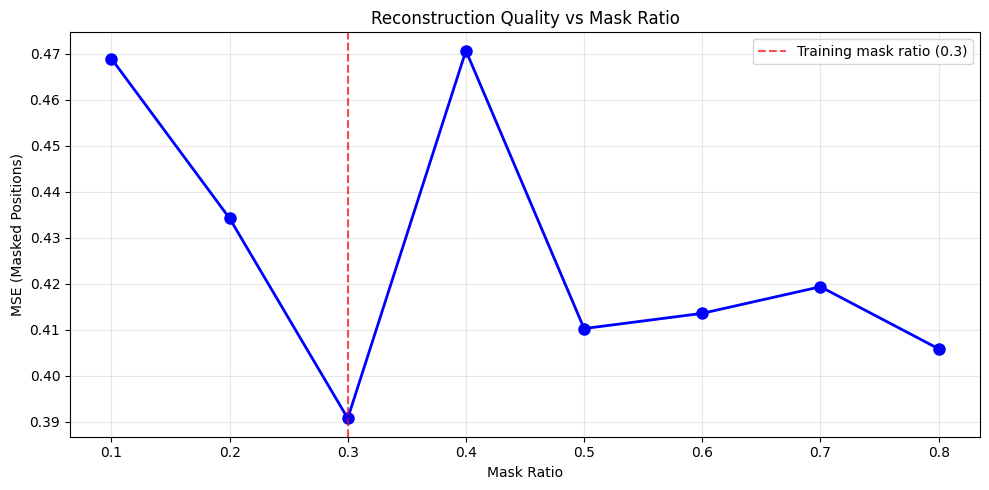


MSE by Mask Ratio:
  10.0%: 0.4690
  20.0%: 0.4342
  30.0%: 0.3907
  40.0%: 0.4707
  50.0%: 0.4102
  60.0%: 0.4136
  70.0%: 0.4193
  80.0%: 0.4058


In [13]:
# Test with different mask ratios
mask_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
mse_by_ratio = []

# Use a fresh batch for each ratio test
test_batch = next(iter(test_loader))

for ratio in mask_ratios:
    results = reconstruct_batch(model, test_batch, mask_ratio=ratio)
    metrics = compute_batch_metrics(results)
    mse_by_ratio.append(metrics["mse_masked_mean"])

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mask_ratios, mse_by_ratio, 'bo-', markersize=8, linewidth=2)
ax.axvline(x=0.3, color='red', linestyle='--', alpha=0.7, label='Training mask ratio (0.3)')
ax.set_xlabel('Mask Ratio')
ax.set_ylabel('MSE (Masked Positions)')
ax.set_title('Reconstruction Quality vs Mask Ratio')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nMSE by Mask Ratio:")
for ratio, mse in zip(mask_ratios, mse_by_ratio):
    print(f"  {ratio:.1%}: {mse:.4f}")

## Random Sample Gallery

Display a grid of random test samples with their reconstructions.

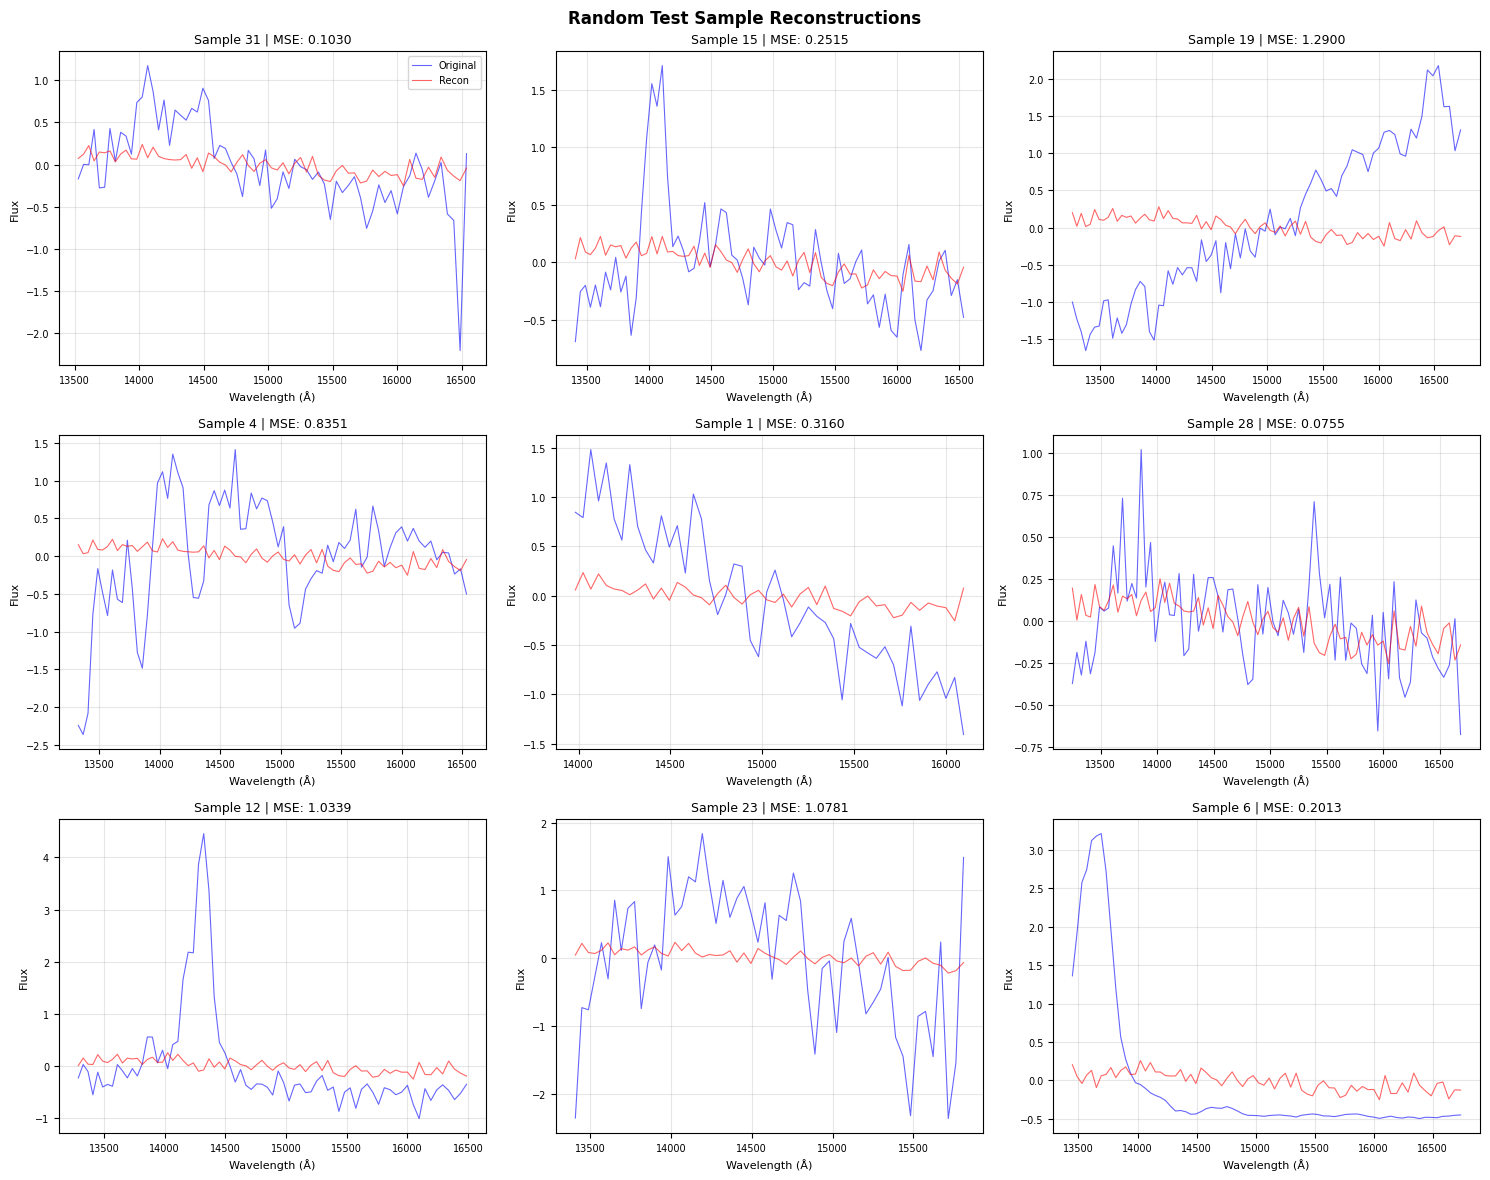

In [14]:
def plot_sample_gallery(results, n_samples=9, figsize=(15, 12)):
    """Plot a gallery of reconstruction comparisons."""
    n_cols = 3
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()
    
    # Randomly select samples
    batch_size = results["original"].shape[0]
    sample_indices = np.random.choice(batch_size, size=min(n_samples, batch_size), replace=False)
    
    for ax_idx, sample_idx in enumerate(sample_indices):
        ax = axes[ax_idx]
        
        wavelength = results["wavelength"][sample_idx]
        original = results["original_norm"][sample_idx]
        reconstruction = results["reconstruction"][sample_idx]
        valid_mask = results["valid_mask"][sample_idx].astype(bool)
        train_mask = results["train_mask"][sample_idx].astype(bool)
        
        # Get valid positions
        wl_valid = wavelength[valid_mask]
        orig_valid = original[valid_mask]
        recon_valid = reconstruction[valid_mask]
        mask_valid = train_mask[valid_mask]
        
        # Sort by wavelength
        sort_idx = np.argsort(wl_valid)
        wl_sorted = wl_valid[sort_idx]
        orig_sorted = orig_valid[sort_idx]
        recon_sorted = recon_valid[sort_idx]
        mask_sorted = mask_valid[sort_idx]
        
        # Plot
        ax.plot(wl_sorted, orig_sorted, 'b-', alpha=0.6, linewidth=0.8, label='Original')
        ax.plot(wl_sorted, recon_sorted, 'r-', alpha=0.6, linewidth=0.8, label='Recon')
        
        # Compute MSE
        orig_masked = orig_sorted[mask_sorted]
        recon_masked = recon_sorted[mask_sorted]
        mse = np.mean((orig_masked - recon_masked) ** 2) if len(orig_masked) > 0 else 0
        
        ax.set_title(f'Sample {sample_idx} | MSE: {mse:.4f}', fontsize=9)
        ax.set_xlabel('Wavelength (Å)', fontsize=8)
        ax.set_ylabel('Flux', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3)
        
        if ax_idx == 0:
            ax.legend(fontsize=7, loc='upper right')
    
    # Hide unused axes
    for ax_idx in range(len(sample_indices), len(axes)):
        axes[ax_idx].set_visible(False)
    
    plt.suptitle('Random Test Sample Reconstructions', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    return fig

# Get a new batch and plot gallery
test_batch = next(iter(test_loader))
results = reconstruct_batch(model, test_batch, mask_ratio=0.3)
fig = plot_sample_gallery(results, n_samples=9)

## Summary

The MA-SpecFormer model demonstrates reasonable reconstruction capability on the test split. Key observations:

1. **Masked Position Reconstruction**: The model can reasonably predict masked flux values based on context from surrounding wavelengths
2. **Mask Ratio Sensitivity**: As expected, reconstruction quality degrades with higher mask ratios
3. **Spectral Features**: The model captures overall spectral shape and trends

These reconstruction results validate that the self-supervised pre-training objective is learning meaningful representations of the spectrum data.